In [1]:
%%writefile lab8_solution.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest


# ==========================================================
# DATASET (PROVIDED)
# ==========================================================

def load_fraud_data():
    """
    Generates a synthetic dataset for fraud detection.

    The dataset contains two features:
    - Transaction Amount
    - Time Gap Since Last Transaction

    The data consists of:
    - Normally distributed points representing legitimate transactions
    - Uniformly distributed outliers representing fraudulent transactions

    Returns:
    --------
    X : np.ndarray of shape (N, 2)
        Feature matrix

    y : np.ndarray of shape (N,)
        Labels where:
        1  -> Normal transaction
        -1 -> Fraudulent transaction
    """

    np.random.seed(42)

    normal = np.random.multivariate_normal(
        mean=[50, 30],
        cov=[[100, 20],[20, 50]],
        size=300
    )

    fraud = np.random.uniform(
        low=[0, 0],
        high=[120, 100],
        size=(40,2)
    )

    X = np.vstack([normal, fraud])

    y = np.ones(len(X))
    y[-40:] = -1

    return X, y


# ==========================================================
# ISOLATION FOREST
# ==========================================================

def fit_isolation_forest(X):
    """
    Trains an Isolation Forest model on the given dataset.

    The model should learn the structure of the data and identify
    patterns corresponding to normal behavior. It uses random
    partitioning to isolate anomalies.

    Parameters:
    -----------
    X : np.ndarray of shape (N, 2)
        Input feature matrix

    Returns:
    --------
    model :
        Trained Isolation Forest model
    """
    model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
    model.fit(X)
    return model


def predict_iforest(model, X):
    """
    Predicts whether each data point is normal or anomalous
    using a trained Isolation Forest model.

    Parameters:
    -----------
    model :
        Trained Isolation Forest model

    X : np.ndarray of shape (N, 2)
        Input feature matrix

    Returns:
    --------
    predictions : np.ndarray of shape (N,)
        Predicted labels:
        1  -> Normal
        -1 -> Anomaly
    """
    return model.predict(X)


def compute_iforest_scores(model, X):
    """
    Computes anomaly scores for each data point.

    These scores reflect how easily a point is isolated
    by the model. Points that are easier to isolate are
    more likely to be anomalies.

    Parameters:
    -----------
    model :
        Trained Isolation Forest model

    X : np.ndarray of shape (N, 2)

    Returns:
    --------
    scores : np.ndarray of shape (N,)
        Anomaly scores for each data point
    """
    # score_samples returns negative average path lengths;
    # more negative = more anomalous
    return model.score_samples(X)


# ==========================================================
# GAUSSIAN (FROM SCRATCH)
# ==========================================================

def compute_gaussian_params(X):
    """
    Estimates the parameters of a multivariate Gaussian distribution.

    The parameters include:
    - Mean vector representing the center of the data
    - Covariance matrix representing the spread and relationship
      between features

    Parameters:
    -----------
    X : np.ndarray of shape (N, 2)

    Returns:
    --------
    mu : np.ndarray of shape (2,)
        Mean vector

    sigma : np.ndarray of shape (2, 2)
        Covariance matrix
    """
    N = X.shape[0]
    mu = (1 / N) * np.sum(X, axis=0)                    # shape (2,)
    diff = X - mu                                         # shape (N, 2)
    sigma = (1 / N) * (diff.T @ diff)                    # shape (2, 2)
    return mu, sigma


def gaussian_density(X, mu, sigma):
    """
    Computes the probability density of each data point under
    a multivariate Gaussian distribution.

    Points closer to the mean will have higher density values,
    while points far from the mean will have lower values.

    Parameters:
    -----------
    X : np.ndarray of shape (N, 2)

    mu : np.ndarray of shape (2,)
        Mean vector

    sigma : np.ndarray of shape (2, 2)
        Covariance matrix

    Returns:
    --------
    densities : np.ndarray of shape (N,)
        Probability density values for each data point
    """
    d = X.shape[1]
    diff = X - mu                                                     # (N, 2)
    sigma_inv = np.linalg.inv(sigma)                                  # (2, 2)
    # Mahalanobis exponent: -0.5 * (x-mu)^T Sigma^-1 (x-mu)  per point
    exponent = -0.5 * np.sum((diff @ sigma_inv) * diff, axis=1)      # (N,)
    coeff = 1.0 / ((2 * np.pi) ** (d / 2) * np.sqrt(np.linalg.det(sigma)))
    return coeff * np.exp(exponent)


def predict_gaussian(X, mu, sigma, threshold):
    """
    Classifies data points as normal or anomalous based on
    their probability density under the Gaussian model.

    Points with density below the specified threshold are
    considered anomalies.

    Parameters:
    -----------
    X : np.ndarray of shape (N, 2)

    mu : np.ndarray
        Mean vector

    sigma : np.ndarray
        Covariance matrix

    threshold : float
        Decision threshold for anomaly detection

    Returns:
    --------
    predictions : np.ndarray of shape (N,)
        Predicted labels:
        1  -> Normal
        -1 -> Anomaly
    """
    densities = gaussian_density(X, mu, sigma)
    predictions = np.where(densities >= threshold, 1, -1)
    return predictions


# ==========================================================
# VISUALIZATION
# ==========================================================

def plot_points(X, labels, title):
    """
    Plots the dataset in a 2D feature space.

    Points are visualized based on their labels, allowing
    comparison between normal and anomalous transactions.

    Parameters:
    -----------
    X : np.ndarray of shape (N, 2)

    labels : np.ndarray of shape (N,)
        Labels for each point

    title : str
        Title of the plot
    """
    plt.scatter(X[:,0], X[:,1], c=labels)
    plt.title(title)


def plot_decision_boundary(model_or_fn, X, method):
    """
    Visualizes the decision regions of the anomaly detection method.

    The plot should show how the model separates normal data
    from anomalous data across the feature space.

    Parameters:
    -----------
    model_or_fn :
        Trained model or function used for prediction

    X : np.ndarray of shape (N, 2)

    method : str
        Identifier for the method ("iforest" or "gaussian")

    Returns:
    --------
    None
    """
    # Build a fine meshgrid spanning the feature space
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]

    if method == "iforest":
        # model_or_fn is the trained IsolationForest model
        zz = model_or_fn.predict(grid)
    elif method == "gaussian":
        # model_or_fn is a callable: fn(X) -> predictions
        zz = model_or_fn(grid)
    else:
        raise ValueError(f"Unknown method: {method}")

    zz = zz.reshape(xx.shape)

    plt.contourf(xx, yy, zz, levels=[-2, 0, 2], alpha=0.3,
                 colors=["#ff9999", "#99ccff"])
    plt.contour(xx, yy, zz, levels=[0], colors="black", linewidths=1.5)
    plt.scatter(X[:, 0], X[:, 1], c="black", s=10, alpha=0.5)
    plt.xlabel("Transaction Amount")
    plt.ylabel("Time Gap Since Last Transaction")
    plt.title(f"Decision Boundary — {method}")

Writing lab8_solution.py


In [2]:
from lab8_solution import *

def test_dataset():
    X, y = load_fraud_data()
    print("Dataset shape:", X.shape)
    assert X.shape[1] == 2
    print("test_dataset PASSED")

def test_iforest():
    X, _ = load_fraud_data()
    model = fit_isolation_forest(X)
    labels = predict_iforest(model, X)
    print("IF labels OK")
    assert set(labels).issubset({-1, 1})
    print("test_iforest PASSED")

def test_gaussian_params():
    X, _ = load_fraud_data()
    mu, sigma = compute_gaussian_params(X)
    print("Gaussian params OK")
    assert mu.shape[0] == 2
    print("test_gaussian_params PASSED")

def test_density():
    X, _ = load_fraud_data()
    mu, sigma = compute_gaussian_params(X)
    d = gaussian_density(X, mu, sigma)
    print("Density OK")
    assert len(d) == len(X)
    print("test_density PASSED")

test_dataset()
test_iforest()
test_gaussian_params()
test_density()

Dataset shape: (340, 2)
test_dataset PASSED
IF labels OK
test_iforest PASSED
Gaussian params OK
test_gaussian_params PASSED
Density OK
test_density PASSED


Model trained: IsolationForest(contamination=0.1, random_state=42)
Predicted anomalies: 34  |  Normal: 306
Actual   anomalies: 40  |  Normal: 300

Anomaly score range: [-0.7444, -0.3608]
Lower scores = more anomalous


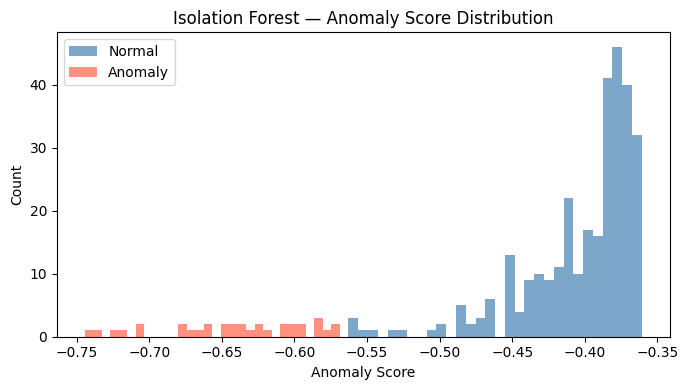

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from lab8_solution import *

X, y = load_fraud_data()

# Task 1: Train
model = fit_isolation_forest(X)
print("Model trained:", model)

# Task 2: Predict
if_labels = predict_iforest(model, X)
n_anomalies = np.sum(if_labels == -1)
n_normal    = np.sum(if_labels ==  1)
print(f"Predicted anomalies: {n_anomalies}  |  Normal: {n_normal}")
print(f"Actual   anomalies: {np.sum(y == -1)}  |  Normal: {np.sum(y == 1)}")

# Task 3: Anomaly scores
scores = compute_iforest_scores(model, X)
print(f"\nAnomaly score range: [{scores.min():.4f}, {scores.max():.4f}]")
print("Lower scores = more anomalous")

# Quick score histogram
plt.figure(figsize=(7, 4))
plt.hist(scores[if_labels ==  1], bins=30, alpha=0.7, label="Normal",   color="steelblue")
plt.hist(scores[if_labels == -1], bins=30, alpha=0.7, label="Anomaly",  color="tomato")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Isolation Forest — Anomaly Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Task 4: Gaussian parameters
mu, sigma = compute_gaussian_params(X)
print("Mean vector (mu):\n", mu)
print("\nCovariance matrix (sigma):\n", sigma)

# Task 5: Probability densities
densities = gaussian_density(X, mu, sigma)
print(f"\nDensity range: [{densities.min():.6f}, {densities.max():.6f}]")

# Task 6: Threshold experiments
thresholds = [1e-5, 1e-4, 5e-4]

for eps in thresholds:
    g_labels = predict_gaussian(X, mu, sigma, threshold=eps)
    print(f"  threshold={eps:.0e}  ->  anomalies={np.sum(g_labels==-1)}, normal={np.sum(g_labels==1)}")

Mean vector (mu):
 [50.47910773 33.25196043]

Covariance matrix (sigma):
 [[226.05720019  10.6743369 ]
 [ 10.6743369  206.38275521]]

Density range: [0.000000, 0.000738]
  threshold=1e-05  ->  anomalies=19, normal=321
  threshold=1e-04  ->  anomalies=32, normal=308
  threshold=5e-04  ->  anomalies=137, normal=203


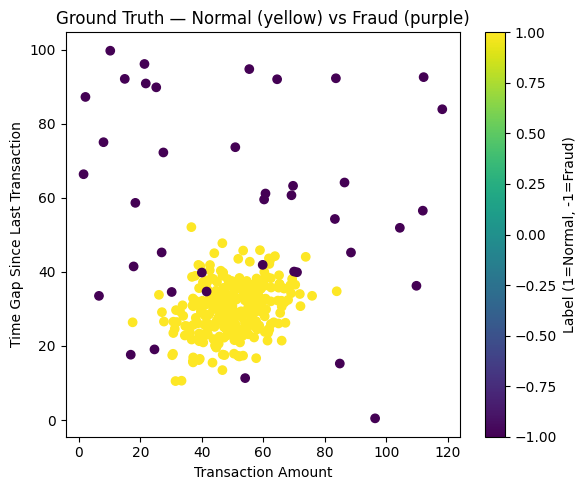

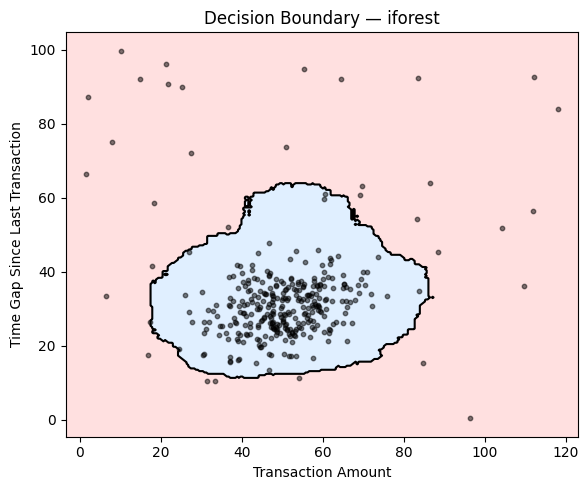

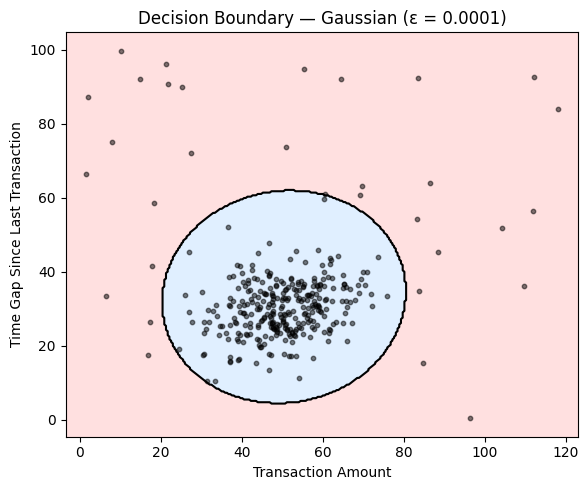

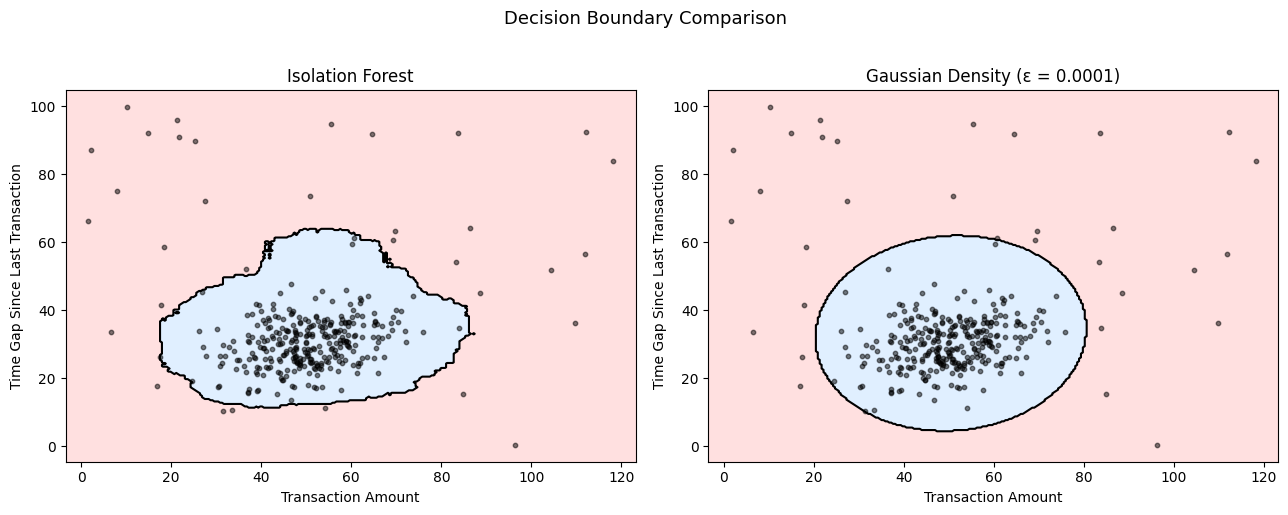

In [5]:
# ---- Task 7: Visualize the raw dataset ----
plt.figure(figsize=(6, 5))
plot_points(X, y, title="Ground Truth — Normal (yellow) vs Fraud (purple)")
plt.xlabel("Transaction Amount")
plt.ylabel("Time Gap Since Last Transaction")
plt.colorbar(label="Label (1=Normal, -1=Fraud)")
plt.tight_layout()
plt.show()

# ---- Task 8a: Isolation Forest decision boundary ----
plt.figure(figsize=(6, 5))
plot_decision_boundary(model, X, method="iforest")
plt.tight_layout()
plt.show()

# ---- Task 8b: Gaussian decision boundary ----
# Pick a threshold that gives reasonable separation
chosen_threshold = 1e-4
gauss_fn = lambda Z: predict_gaussian(Z, mu, sigma, threshold=chosen_threshold)

plt.figure(figsize=(6, 5))
plot_decision_boundary(gauss_fn, X, method="gaussian")
plt.title(f"Decision Boundary — Gaussian (ε = {chosen_threshold})")
plt.tight_layout()
plt.show()

# ---- Side-by-side comparison ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plt.sca(axes[0])
plot_decision_boundary(model, X, method="iforest")
axes[0].set_title("Isolation Forest")

plt.sca(axes[1])
plot_decision_boundary(gauss_fn, X, method="gaussian")
axes[1].set_title(f"Gaussian Density (ε = {chosen_threshold})")

plt.suptitle("Decision Boundary Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()